In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Наложение и удаление шума

In [2]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

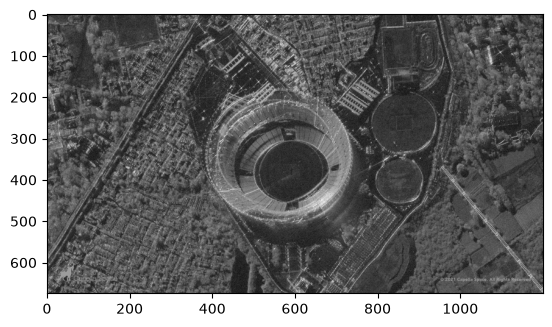

In [3]:
plt.imshow(image_gray, cmap="gray")

In [4]:
# Gaussian noise
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[  0,  16,   0, ..., 111,   0,  80],
       [  1, 104,  68, ...,   0, 103,   0],
       [  0,   0,  51, ...,   0,   0, 145],
       ...,
       [  0,   0,  39, ..., 255,   0,  15],
       [  0,  34,   0, ...,   0,   5, 135],
       [160, 204,   0, ...,  21,   0, 109]],
      shape=(675, 1200), dtype=uint8)

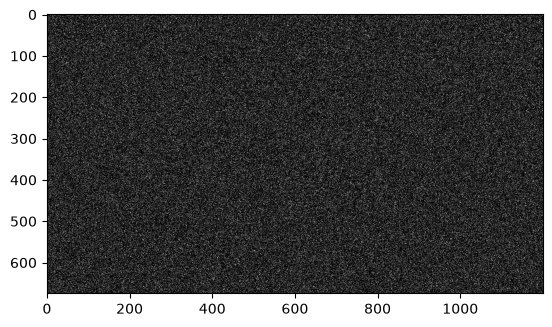

In [5]:
plt.imshow(noise_gauss, cmap="gray")

In [6]:
# Salt and pepper
noise =  np.random.randint(0, 101, size = (image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel = np.where(noise == 100)

In [7]:
bg_image = np.ones(image_gray.shape, np.uint8) * 128

In [8]:
bg_image[zeros_pixel] = 0
bg_image[ones_pixel] = 255

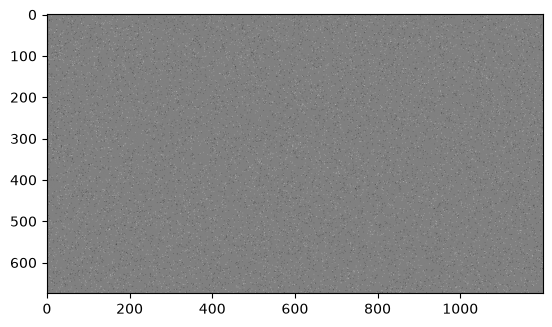

In [9]:
plt.imshow(bg_image, cmap="gray")

In [10]:
image_noise_gauss = cv2.add(image_gray,noise_gauss)

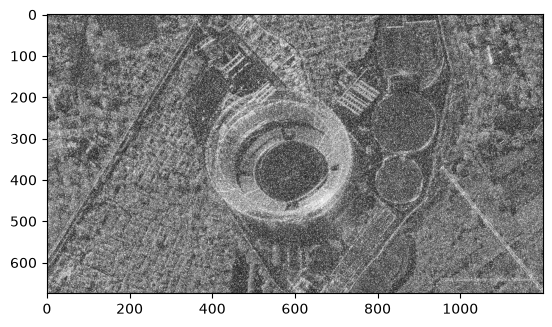

In [11]:
plt.imshow(image_noise_gauss, cmap="gray")

In [12]:
from skimage.metrics import structural_similarity, mean_squared_error
mse_gauss = mean_squared_error(image_gray, image_noise_gauss)
(ssim, diff) = structural_similarity(image_gray, image_noise_gauss, full=True)
print(mse_gauss, ssim)

4230.673058024691 0.18699266800035377


In [13]:
image_gauss_median = cv2.medianBlur(image_noise_gauss, 3)

In [14]:
mse_gauss_median = mean_squared_error(image_gray, image_gauss_median)
(ssim_gauss_median, diff) = structural_similarity(image_gray,  image_gauss_median, full=True)

In [15]:
print(mse_gauss_median, ssim_gauss_median)

1038.0453432098766 0.42824305715634176


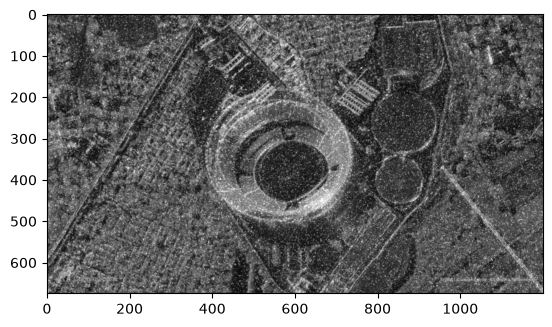

In [16]:
plt.imshow(image_gauss_median, cmap="gray")

In [17]:
import copy

image_sp = copy.deepcopy(image_gray)

image_sp[zeros_pixel] = 0
image_sp[ones_pixel] = 255

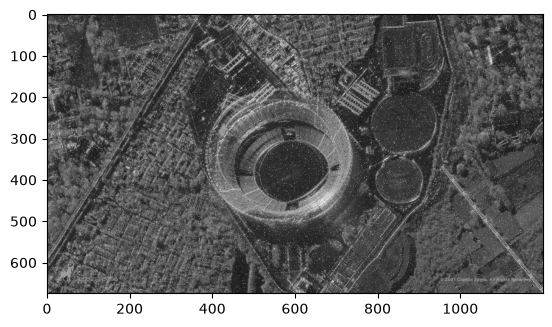

In [18]:
plt.imshow(image_sp, cmap="gray")

In [19]:
mse_sp = mean_squared_error(image_gray, image_sp)
(ssim_sp, diff) = structural_similarity(image_gray, image_sp, full=True)
print(mse_sp, ssim_sp)

387.8477419753086 0.7194408035580743


In [20]:
image_sp_median = cv2.medianBlur(image_sp, 3)

In [21]:
mse_sp_median = mean_squared_error(image_gray, image_sp_median)
(ssim_sp_median, diff) = structural_similarity(image_gray, image_sp_median, full=True)
print(mse_sp_median, ssim_sp_median)

95.71126913580247 0.816187354088


# Другие типы фильтров

In [22]:
image_gauss_gauss = cv2.GaussianBlur(image_noise_gauss,(5,5),0)

In [23]:
image_gauss_bilat = cv2.bilateralFilter(image_noise_gauss,9,75,75)

In [24]:
image_gauss_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h = 20)

In [25]:
import math

def geom(a):
    prod = 1
    for i in range(a.shape[0]):
        prod1 = 1
        for j in range(a.shape[1]):
            prod1 *= a[i,j]
        prod1 = math.pow(prod1, 1.0/9.0)
        prod *= prod1
    return prod

def proc(img, filter):
    img_res = copy.deepcopy(img)
    for i in range(0,img.shape[0] -2):
        for j in range(0,img.shape[1] -2):
            img_res[i:i+3, j:j+3] = filter(img[i:i+3, j:j+3])
    return img_res
    
res = proc(image_noise_gauss, geom)


C:\Users\Пользователь\AppData\Local\Temp\ipykernel_3316\164976186.py:8: RuntimeWarning: overflow encountered in scalar multiply
  prod1 *= a[i,j]


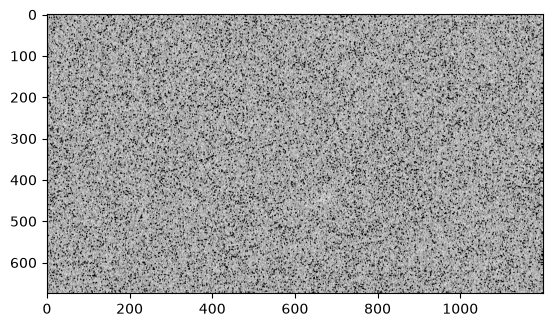

In [26]:
plt.imshow(res, cmap="gray")

In [27]:
mse_geom = mean_squared_error(image_gray, res)
(ssim_geom, diff) = structural_similarity(image_gray, res, full=True)
print(mse_geom, ssim_geom)

6551.976648148148 0.02746126776511089



# 2D свертка

In [28]:
# averaging filter
kernel_5 = np.ones((5,5),np.float32)/25
image_k5 = cv2.filter2D(image_gray,-1,kernel_5)
# blured_image = cv2.blur(img,(5,5))
image_b5 = cv2.blur(image_gray,(5,5))

In [29]:
mse_kb = mean_squared_error(image_k5, image_b5)
(ssim_kb, diff) = structural_similarity(image_k5, image_b5, full=True)
print(mse_kb, ssim_kb)

0.0 1.0


In [30]:
# Laplasian
kernel_lapl = np.array([[0,-10,0],
                        [-10,40,-10],
                        [0,-10,0]], np.float32)

In [31]:
image_lapl = cv2.filter2D(image_gray,-1,kernel_lapl) 

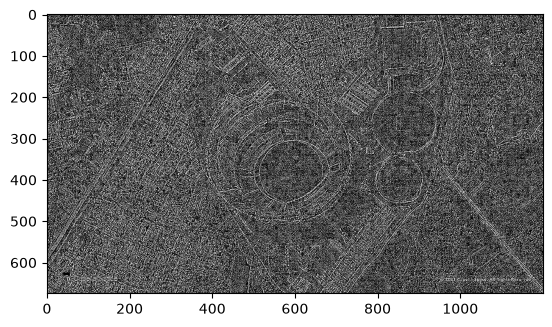

In [32]:
plt.imshow(image_lapl, cmap="gray")

In [33]:
# ДЗ 2
# Зашумить изображение при помощи шума гаусса, постоянного шума.
# Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.
# Выяснить, какой фильтр показал лучший результат фильтрации шума.

# Решение ДЗ 2: наложение и удаление шума (`sar_1.jpg`)

**Задание.** Зашумить изображение гауссовым и постоянным шумом; протестировать медианный фильтр, фильтр Гаусса,
билатеральный фильтр и фильтр нелокальных средних с различными параметрами; выяснить, какой фильтр лучше всего убирает шум.

**План.**
1. Модель шума из лекции: $f(i,j)=s(i,j)+n(i,j)$, где $s$ — исходное (чистое) изображение, $n$ — шум.
2. Два типа шума: гауссов и постоянный (равномерный, `uniform`).
3. Четыре фильтра, для каждого — сетка параметров.
4. Сравнение по MSE, SSIM и PSNR относительно **чистого** изображения и выбор лучшего фильтра.

In [34]:
import pandas as pd
from IPython.display import display
from skimage.metrics import structural_similarity, mean_squared_error, peak_signal_noise_ratio

pd.set_option('display.width', 200)
pd.set_option('display.max_rows', 200)

SEED = 42                      # фиксируем генераторы, чтобы результаты воспроизводились
np.random.seed(SEED)
cv2.setRNGSeed(SEED)

clean = image_gray             # s(i, j): чистое изображение в оттенках серого (из ячейки выше)
print("clean:", clean.shape, clean.dtype, "| mean = %.2f, std = %.2f" % (clean.mean(), clean.std()))


def quality(ref, img):
    # Метрики качества img относительно эталона ref (все изображения 8-битные)
    return {'MSE': mean_squared_error(ref, img),
            'SSIM': structural_similarity(ref, img, data_range=255),
            'PSNR': peak_signal_noise_ratio(ref, img, data_range=255)}

clean: (675, 1200) uint8 | mean = 78.24, std = 31.40


## 1. Наложение шума

**Гауссов шум:** $p(z)=\frac{1}{\sqrt{2\pi}\sigma}e^{-\frac{(z-\mu)^2}{2\sigma^2}}$.
**Постоянный (равномерный) шум:** $p(z)=\frac{1}{b-a}$ при $a\le z\le b$, иначе 0.

**Знак шума (из `notes.docx`: «шумовые составляющие – положительные элементы»).**
В шаблоне шум записывается в массив `uint8` (`cv2.randn`, `cv2.randu`), поэтому отрицательные значения обнуляются,
а сложение `cv2.add` обрезает результат на 255: шум получается **неотрицательным** и повышает среднюю яркость.
Классическая модель — шум с нулевым средним (знакопеременный). Чтобы не гадать, какой вариант нужен,
сделаны оба и результаты сравниваются в обоих:

* **«неотриц.»** — как в шаблоне и заметках (положительные составляющие);
* **«± (нулевое среднее)»** — знакопеременный шум, сложение в `float` и обрезка до [0, 255].

У неотрицательного шума среднее больше нуля, и он сдвигает яркость всего снимка (для гауссова $\sigma/\sqrt{2\pi}\approx 12$, для постоянного $U[0,100)$ около 50).
Ни один из фильтров этот сдвиг не убирает, а MSE при сдвиге в 50 уровней не может опуститься ниже $50^2=2500$ независимо от качества фильтра.
Поэтому для неотрицательного шума из результата фильтрации вычитается **известное теоретическое среднее шума** (оно определяется параметрами генератора, а не чистым снимком).
Для сравнения в таблице ниже приведены метрики и без вычитания, и после него.

In [35]:
def add_gaussian_noise(img, sigma, mean=0, nonneg=True):
    # Гауссов шум N(mean, sigma).
    if nonneg:                                   # как в шаблоне: шум в uint8, отрицательные значения -> 0
        n = np.zeros(img.shape, np.uint8)
        cv2.randn(n, mean, sigma)
        return cv2.add(img, n)                   # сложение с насыщением на 255
    n = np.random.normal(mean, sigma, img.shape)
    return np.clip(np.round(img + n), 0, 255).astype(np.uint8)


def add_uniform_noise(img, a, b, nonneg=True):
    # Постоянный (равномерный) шум на отрезке [a, b].
    if nonneg:                                   # требует 0 <= a < b <= 255
        n = np.zeros(img.shape, np.uint8)
        cv2.randu(n, a, b)
        return cv2.add(img, n)
    n = np.random.uniform(a, b, img.shape)
    return np.clip(np.round(img + n), 0, 255).astype(np.uint8)


SIGMA = 30                                       # СКО гауссова шума
scenarios = {
    'Гаусс, неотриц.':          add_gaussian_noise(clean, SIGMA, nonneg=True),
    'Постоянный, неотриц.':     add_uniform_noise(clean, 0, 100, nonneg=True),         # U[0, 100],  СКО ~ 28.9
    'Гаусс, ± (нул. среднее)':  add_gaussian_noise(clean, SIGMA, nonneg=False),
    'Постоянный, ± (нул. ср.)': add_uniform_noise(clean, -50, 50, nonneg=False),       # U[-50, 50], СКО ~ 28.9
}

# Известное (теоретическое) среднее добавленного шума. У неотрицательного шума оно > 0 и сдвигает яркость всего снимка.
OFFSETS = {
    'Гаусс, неотриц.':          SIGMA / np.sqrt(2 * np.pi),   # среднее max(0, N(0, sigma)) = sigma / sqrt(2*pi)
    'Постоянный, неотриц.':     (0 + 100 - 1) / 2,            # целые 0..99, среднее 49.5
    'Гаусс, ± (нул. среднее)':  0.0,
    'Постоянный, ± (нул. ср.)': 0.0,
}


def compensate(img, offset):
    # Вычитает известное среднее шума (с обрезкой до [0, 255]).
    return np.clip(np.round(img.astype(np.float64) - offset), 0, 255).astype(np.uint8)


rows = []
for name, im in scenarios.items():
    q_raw = quality(clean, im)
    q_cmp = quality(clean, compensate(im, OFFSETS[name]))
    rows.append({'шум': name, 'сдвиг ярк.': im.mean() - clean.mean(), 'MSE': q_raw['MSE'], 'SSIM': q_raw['SSIM'],
                 'MSE после вычитания среднего': q_cmp['MSE'], 'SSIM после вычитания среднего': q_cmp['SSIM']})
noise_stats = pd.DataFrame(rows).set_index('шум')
display(noise_stats.round(3))

,сдвиг ярк.,MSE,SSIM,MSE после вычитания среднего,SSIM после вычитания среднего
шум,,,,,
"Гаусс, неотриц.",11.973,450.737,0.623,307.382,0.630
"Постоянный, неотриц.",49.437,3274.187,0.369,821.709,0.416
"Гаусс, ± (нул. среднее)",0.316,863.089,0.406,863.089,0.406
"Постоянный, ± (нул. ср.)",0.063,823.599,0.416,823.599,0.416


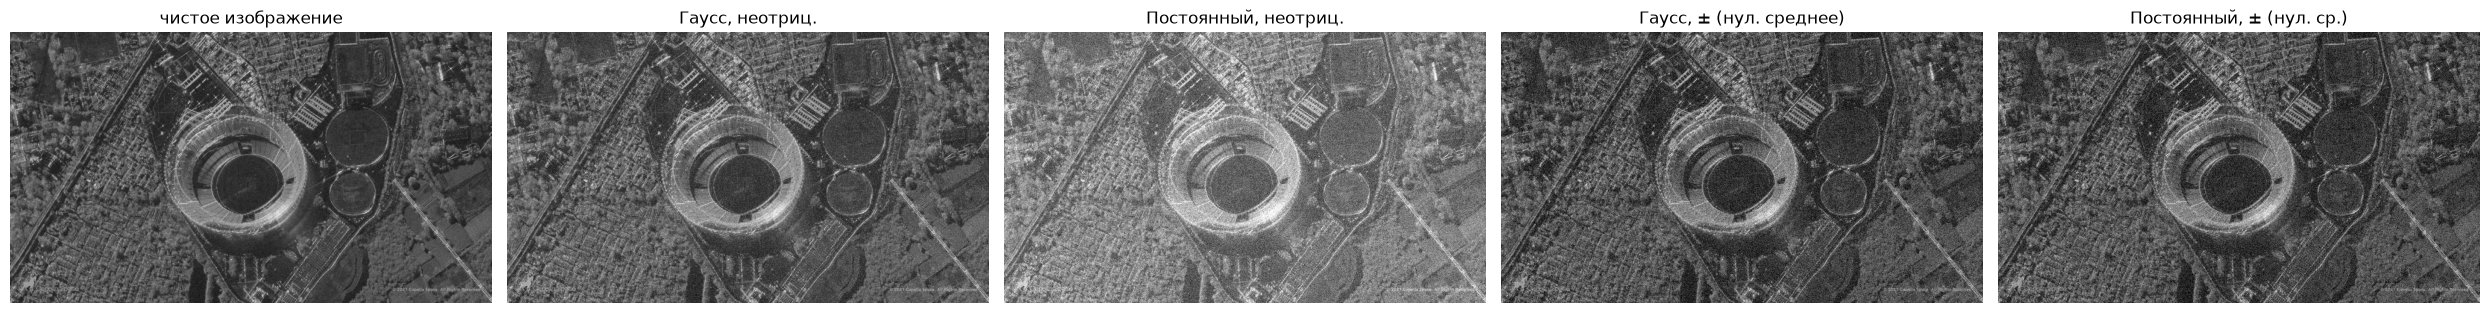

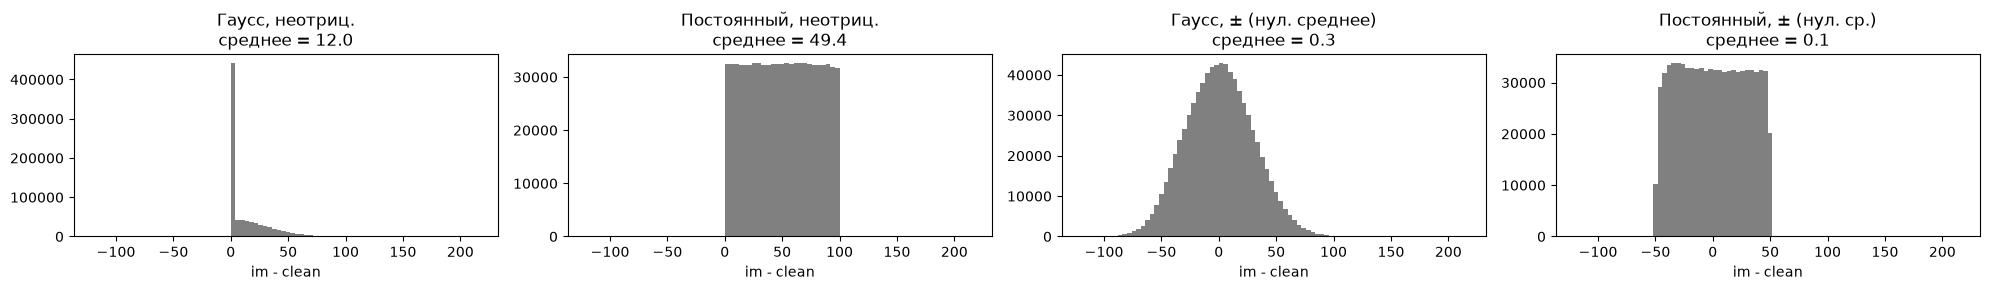

In [36]:
fig, ax = plt.subplots(1, 5, figsize=(25, 4))
ax[0].imshow(clean, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('чистое изображение')
for a, (name, im) in zip(ax[1:], scenarios.items()):
    a.imshow(im, cmap='gray', vmin=0, vmax=255)
    a.set_title(name)
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

# наглядно: распределение добавленного шума (разность зашумлённого и чистого, до обрезки на краях диапазона)
fig, ax = plt.subplots(1, 4, figsize=(20, 3))
for a, (name, im) in zip(ax, scenarios.items()):
    d = im.astype(int) - clean.astype(int)
    a.hist(d.ravel(), bins=np.arange(-120, 220, 4), color='gray')
    a.set_title(name + f'\nсреднее = {d.mean():.1f}')
    a.set_xlabel('im - clean')
plt.tight_layout()
plt.show()

## 2. Фильтры и сетки параметров

| фильтр | функция OpenCV | перебираемые параметры |
|---|---|---|
| медианный | `cv2.medianBlur` | размер окна `k` = 3, 5, 7, 9 |
| Гаусса | `cv2.GaussianBlur` | `sigma` = 0.5, 1, 1.5, 2, 3 (окно подбирается по сигме) + вариант из шаблона: окно 5×5, `sigma` = 0 |
| билатеральный | `cv2.bilateralFilter` | диаметр `d` = 3, 5, 9; `sigmaColor` = 25, 50, 75, 100; `sigmaSpace` = 25, 75 |
| нелокальных средних | `cv2.fastNlMeansDenoising` | сила `h` = 10, 15, 20, 30, 40, 50; окно блока / окно поиска = 5/15, 7/21 |

Качество каждого результата считается относительно **чистого** изображения: чем меньше MSE и больше SSIM и PSNR, тем лучше.

In [37]:
FILTERS = {
    'Median':    lambda img, p: cv2.medianBlur(img, p['k']),
    'Gaussian':  lambda img, p: cv2.GaussianBlur(img, p['ksize'], p['sigma']),
    'Bilateral': lambda img, p: cv2.bilateralFilter(img, p['d'], p['sigmaColor'], p['sigmaSpace']),
    'NLM':       lambda img, p: cv2.fastNlMeansDenoising(img, None, p['h'], p['template'], p['search']),
}

GRIDS = {
    'Median':    [{'k': k} for k in (3, 5, 7, 9)],
    'Gaussian':  [{'ksize': (0, 0), 'sigma': s} for s in (0.5, 1, 1.5, 2, 3)] + [{'ksize': (5, 5), 'sigma': 0}],
    'Bilateral': [{'d': d, 'sigmaColor': sc, 'sigmaSpace': ss}
                  for d in (3, 5, 9) for sc in (25, 50, 75, 100) for ss in (25, 75)],
    'NLM':       [{'h': h, 'template': t, 'search': s}
                  for h in (10, 15, 20, 30, 40, 50) for t, s in ((5, 15), (7, 21))],
}


def apply_filter(fname, p, noisy, offset):
    # Фильтр + вычитание известного среднего шума (сами фильтры сдвиг яркости не убирают).
    return compensate(FILTERS[fname](noisy, p), offset)


def evaluate(ref, noisy, offset):
    # Применяет все фильтры из сеток к noisy и возвращает таблицу метрик.
    rows = []
    for fname, grid in GRIDS.items():
        for p in grid:
            out = apply_filter(fname, p, noisy, offset)
            rows.append({'filter': fname, 'params': str(p), 'p': p, **quality(ref, out)})
    return pd.DataFrame(rows)


results = {}
for name, noisy_img in scenarios.items():
    results[name] = evaluate(clean, noisy_img, OFFSETS[name])
    print(f"{name}: проверено {len(results[name])} комбинаций фильтр + параметры")

Гаусс, неотриц.: проверено 46 комбинаций фильтр + параметры


Постоянный, неотриц.: проверено 46 комбинаций фильтр + параметры


Гаусс, ± (нул. среднее): проверено 46 комбинаций фильтр + параметры


Постоянный, ± (нул. ср.): проверено 46 комбинаций фильтр + параметры


## 3. Результаты для каждого типа шума

Для каждого фильтра ниже показан лучший вариант параметров (по SSIM) и, для справки, качество зашумлённого изображения без фильтрации.

In [38]:
FNAMES = list(FILTERS)
best_tables = {}
for name, df in results.items():
    best = df.loc[df.groupby('filter')['SSIM'].idxmax()].set_index('filter').loc[FNAMES]
    best_tables[name] = best
    base = quality(clean, compensate(scenarios[name], OFFSETS[name]))
    print('=' * 100)
    print(name, '| без фильтрации: MSE = %.1f, SSIM = %.4f, PSNR = %.2f' % (base['MSE'], base['SSIM'], base['PSNR']))
    display(best[['params', 'MSE', 'SSIM', 'PSNR']].round(4))


Гаусс, неотриц. | без фильтрации: MSE = 307.4, SSIM = 0.6302, PSNR = 23.25


,params,MSE,SSIM,PSNR
filter,,,,
Median,{'k': 3},153.4582,0.7315,26.2709
Gaussian,"{'ksize': (0, 0), 'sigma': 1}",128.2056,0.7551,27.0517
Bilateral,"{'d': 3, 'sigmaColor': 75, 'sigmaSpace': 25}",109.7546,0.7866,27.7266
NLM,"{'h': 15, 'template': 5, 'search': 15}",133.5972,0.7522,26.8728


Постоянный, неотриц. | без фильтрации: MSE = 821.7, SSIM = 0.4155, PSNR = 18.98


,params,MSE,SSIM,PSNR
filter,,,,
Median,{'k': 3},311.1080,0.5431,23.2017
Gaussian,"{'ksize': (0, 0), 'sigma': 1}",171.5381,0.6876,25.7872
Bilateral,"{'d': 5, 'sigmaColor': 75, 'sigmaSpace': 25}",185.0551,0.6688,25.4578
NLM,"{'h': 20, 'template': 7, 'search': 21}",285.8873,0.6094,23.5689


Гаусс, ± (нул. среднее) | без фильтрации: MSE = 863.1, SSIM = 0.4063, PSNR = 18.77


,params,MSE,SSIM,PSNR
filter,,,,
Median,{'k': 3},258.0553,0.5890,24.0137
Gaussian,"{'ksize': (0, 0), 'sigma': 1}",174.1576,0.6814,25.7214
Bilateral,"{'d': 5, 'sigmaColor': 75, 'sigmaSpace': 25}",186.4481,0.6646,25.4252
NLM,"{'h': 30, 'template': 5, 'search': 15}",199.8368,0.5988,25.1240


Постоянный, ± (нул. ср.) | без фильтрации: MSE = 823.6, SSIM = 0.4158, PSNR = 18.97


,params,MSE,SSIM,PSNR
filter,,,,
Median,{'k': 3},311.6744,0.5424,23.1938
Gaussian,"{'ksize': (0, 0), 'sigma': 1}",170.1911,0.6878,25.8214
Bilateral,"{'d': 5, 'sigmaColor': 75, 'sigmaSpace': 25}",183.1894,0.6692,25.5018
NLM,"{'h': 20, 'template': 7, 'search': 21}",283.7238,0.6123,23.6018


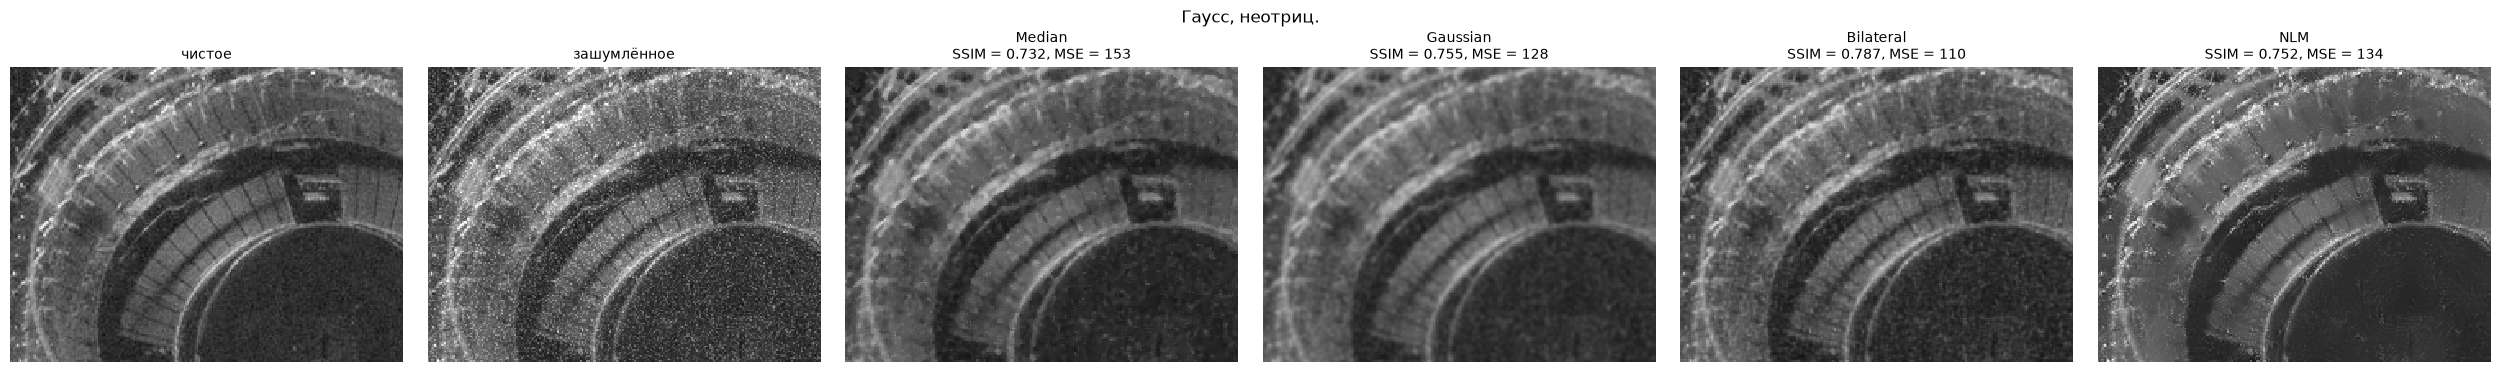

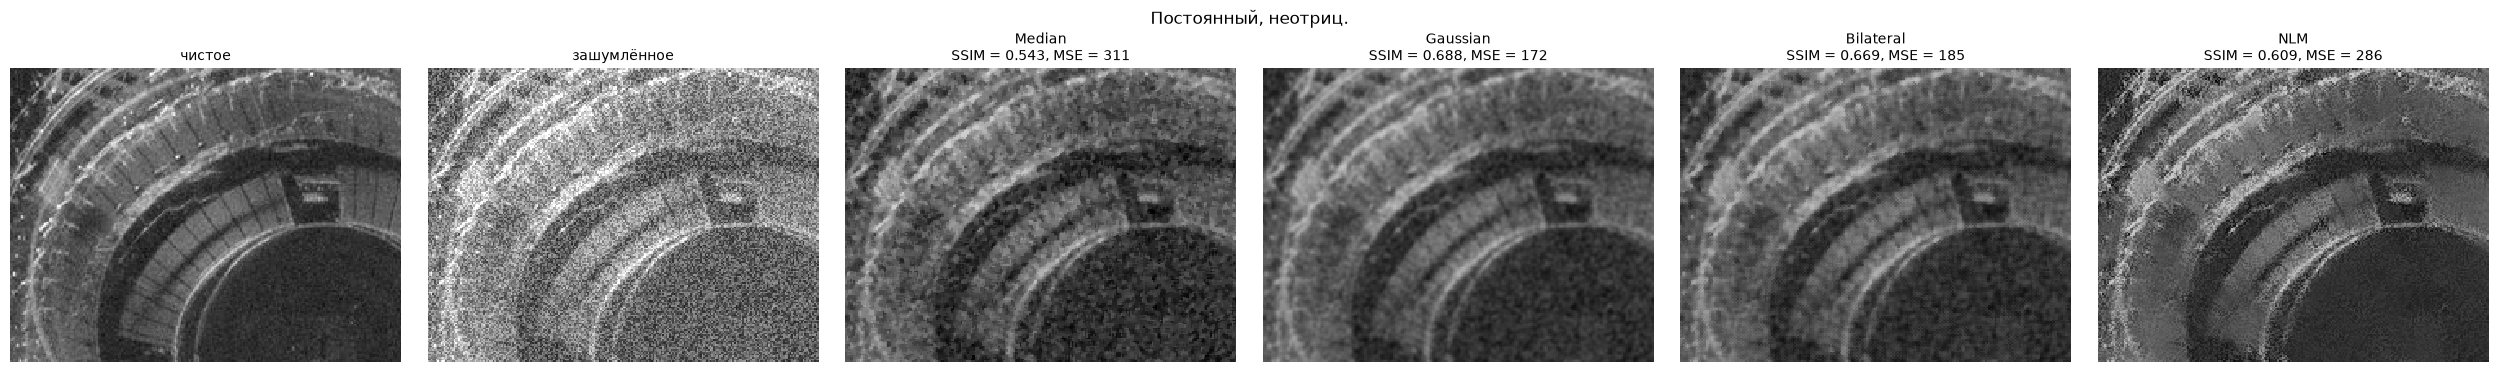

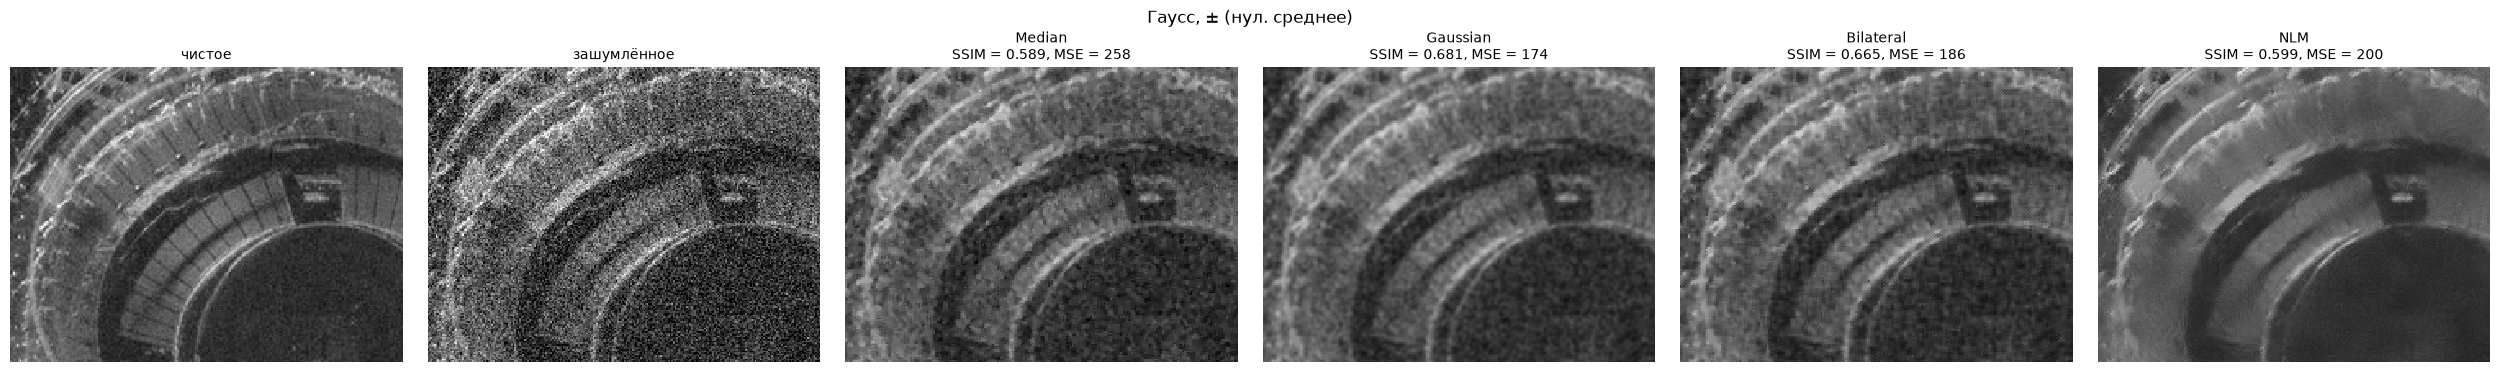

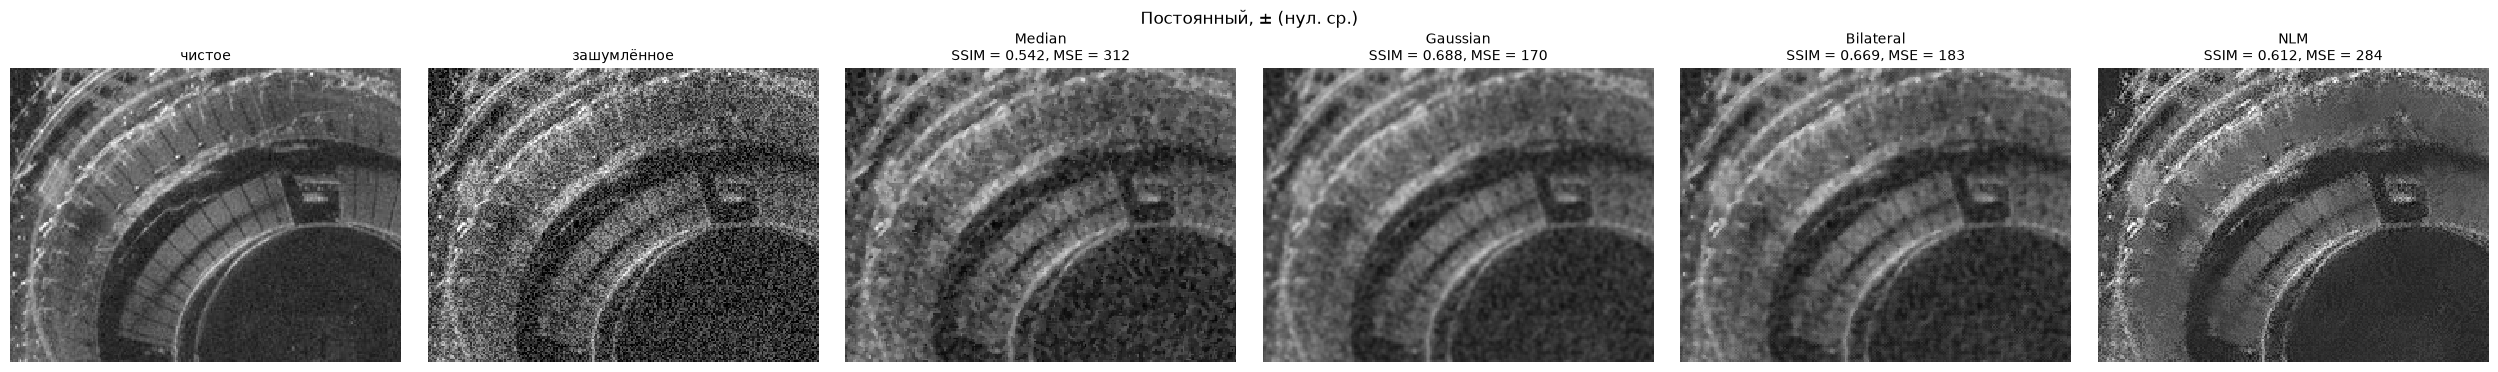

In [39]:
# Визуальное сравнение лучших вариантов на увеличенном фрагменте (трибуны стадиона)
ROI = (slice(210, 390), slice(400, 640))

def show_best(name):
    noisy_img = scenarios[name]
    best = best_tables[name]
    panels = [('чистое', clean[ROI]), ('зашумлённое', noisy_img[ROI])]
    for fname in FNAMES:
        p = best.loc[fname, 'p']
        panels.append((f"{fname}\nSSIM = {best.loc[fname, 'SSIM']:.3f}, MSE = {best.loc[fname, 'MSE']:.0f}",
                       apply_filter(fname, p, noisy_img, OFFSETS[name])[ROI]))
    fig, ax = plt.subplots(1, len(panels), figsize=(4.2 * len(panels), 3.6))
    for a, (title, im) in zip(ax, panels):
        a.imshow(im, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
        a.set_title(title, fontsize=10)
        a.axis('off')
    fig.suptitle(name, y=1.02)
    plt.tight_layout()
    plt.show()

for name in scenarios:
    show_best(name)

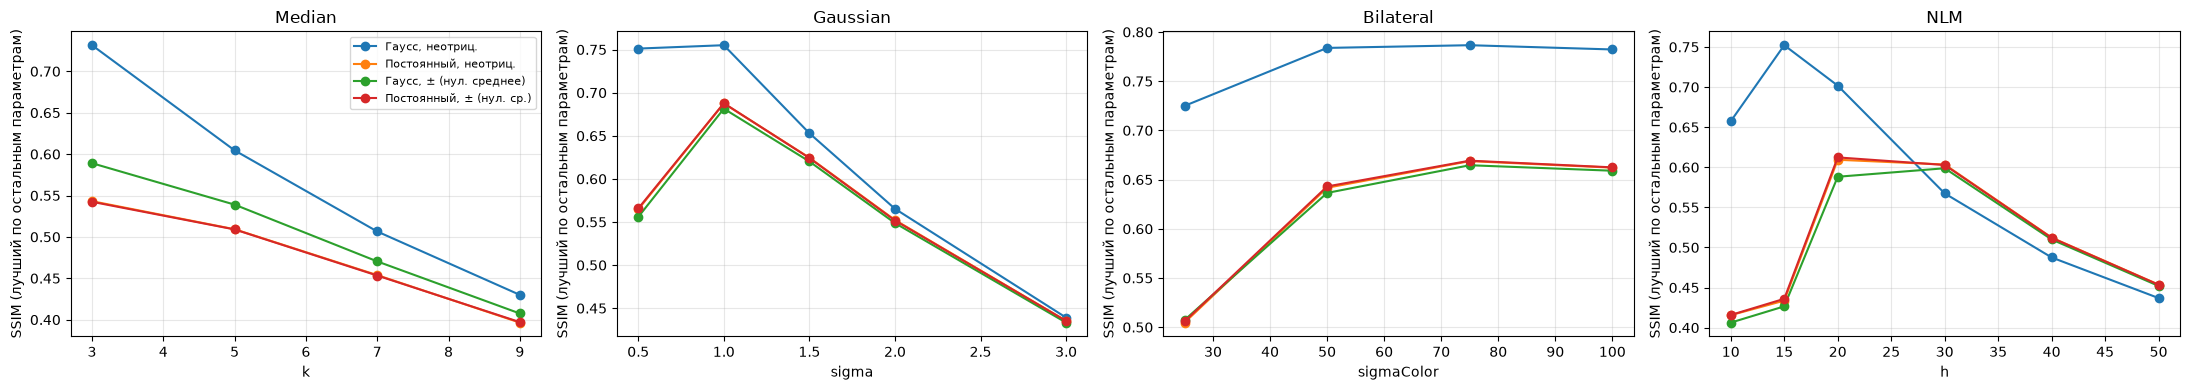

In [40]:
# Как качество зависит от главного параметра каждого фильтра (по остальным параметрам берётся лучший вариант)
KEYS = {'Median': 'k', 'Gaussian': 'sigma', 'Bilateral': 'sigmaColor', 'NLM': 'h'}
fig, ax = plt.subplots(1, 4, figsize=(22, 4))
for a, (fname, key) in zip(ax, KEYS.items()):
    for name, df in results.items():
        sub = df[df['filter'] == fname].copy()
        sub['x'] = sub['p'].map(lambda p: p[key])
        sub = sub[sub['x'] > 0]
        a.plot(*zip(*sub.groupby('x')['SSIM'].max().items()), marker='o', label=name)
    a.set_title(fname)
    a.set_xlabel(key)
    a.set_ylabel('SSIM (лучший по остальным параметрам)')
    a.grid(alpha=.3)
ax[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Итоговое сравнение и выбор лучшего фильтра
Для каждого типа шума отдельно выбираем лучший вариант каждого фильтра по SSIM и сравниваем по MSE и PSNR. Если критерии расходятся, это видно в таблице.

In [41]:
summary = []
for name, df in results.items():
    for criterion, idx in (('SSIM', df['SSIM'].idxmax()), ('MSE', df['MSE'].idxmin()), ('PSNR', df['PSNR'].idxmax())):
        r = df.loc[idx]
        summary.append({'шум': name, 'критерий': criterion, 'лучший фильтр': r['filter'],
                        'параметры': r['params'], 'MSE': r['MSE'], 'SSIM': r['SSIM'], 'PSNR': r['PSNR']})
summary = pd.DataFrame(summary)
display(summary.round(4))

print()
print("Сводная таблица: SSIM лучшего варианта каждого фильтра")
pivot = pd.DataFrame({name: best_tables[name]['SSIM'] for name in scenarios}).round(4)
pivot.loc['(без фильтра)'] = [quality(clean, compensate(scenarios[n], OFFSETS[n]))['SSIM'] for n in scenarios]
display(pivot)

print("Сводная таблица: MSE лучшего варианта каждого фильтра (по SSIM)")
pivot_mse = pd.DataFrame({name: best_tables[name]['MSE'] for name in scenarios}).round(1)
pivot_mse.loc['(без фильтра)'] = [quality(clean, compensate(scenarios[n], OFFSETS[n]))['MSE'] for n in scenarios]
display(pivot_mse)

,шум,критерий,лучший фильтр,параметры,MSE,SSIM,PSNR
0,"Гаусс, неотриц.",SSIM,Bilateral,"{'d': 3, 'sigmaColor': 75, 'sigmaSpace': 25}",109.7546,0.7866,27.7266
1,"Гаусс, неотриц.",MSE,Bilateral,"{'d': 3, 'sigmaColor': 75, 'sigmaSpace': 25}",109.7546,0.7866,27.7266
2,"Гаусс, неотриц.",PSNR,Bilateral,"{'d': 3, 'sigmaColor': 75, 'sigmaSpace': 25}",109.7546,0.7866,27.7266
3,"Постоянный, неотриц.",SSIM,Gaussian,"{'ksize': (0, 0), 'sigma': 1}",171.5381,0.6876,25.7872
4,"Постоянный, неотриц.",MSE,Gaussian,"{'ksize': (0, 0), 'sigma': 1}",171.5381,0.6876,25.7872
5,"Постоянный, неотриц.",PSNR,Gaussian,"{'ksize': (0, 0), 'sigma': 1}",171.5381,0.6876,25.7872
6,"Гаусс, ± (нул. среднее)",SSIM,Gaussian,"{'ksize': (0, 0), 'sigma': 1}",174.1576,0.6814,25.7214
7,"Гаусс, ± (нул. среднее)",MSE,Gaussian,"{'ksize': (0, 0), 'sigma': 1}",174.1576,0.6814,25.7214
8,"Гаусс, ± (нул. среднее)",PSNR,Gaussian,"{'ksize': (0, 0), 'sigma': 1}",174.1576,0.6814,25.7214
9,"Постоянный, ± (нул. ср.)",SSIM,Gaussian,"{'ksize': (0, 0), 'sigma': 1}",170.1911,0.6878,25.8214



Сводная таблица: SSIM лучшего варианта каждого фильтра


,"Гаусс, неотриц.","Постоянный, неотриц.","Гаусс, ± (нул. среднее)","Постоянный, ± (нул. ср.)"
filter,,,,
Median,0.731500,0.543100,0.589000,0.542400
Gaussian,0.755100,0.687600,0.681400,0.687800
Bilateral,0.786600,0.668800,0.664600,0.669200
NLM,0.752200,0.609400,0.598800,0.612300
(без фильтра),0.630215,0.415537,0.406275,0.415793


Сводная таблица: MSE лучшего варианта каждого фильтра (по SSIM)


,"Гаусс, неотриц.","Постоянный, неотриц.","Гаусс, ± (нул. среднее)","Постоянный, ± (нул. ср.)"
filter,,,,
Median,153.500000,311.100000,258.100000,311.700000
Gaussian,128.200000,171.500000,174.200000,170.200000
Bilateral,109.800000,185.100000,186.400000,183.200000
NLM,133.600000,285.900000,199.800000,283.700000
(без фильтра),307.381742,821.708975,863.088668,823.598663


## 5. Проверка устойчивости результата
Выводы выше получены на одной реализации шума (`SEED = 42`). Чтобы убедиться, что разница между фильтрами не случайна, лучшие параметры каждого фильтра
(выбранные выше) применяются к 5 новым реализациям шума с другими значениями `seed`; показаны среднее и СКО SSIM.

In [42]:
def make_scenarios(seed):
    np.random.seed(seed)
    cv2.setRNGSeed(seed)
    return {
        'Гаусс, неотриц.':          add_gaussian_noise(clean, SIGMA, nonneg=True),
        'Постоянный, неотриц.':     add_uniform_noise(clean, 0, 100, nonneg=True),
        'Гаусс, ± (нул. среднее)':  add_gaussian_noise(clean, SIGMA, nonneg=False),
        'Постоянный, ± (нул. ср.)': add_uniform_noise(clean, -50, 50, nonneg=False),
    }

SEEDS = [1, 2, 3, 4, 5]
runs = {name: {f: [] for f in FNAMES} for name in scenarios}
wins = {name: {f: 0 for f in FNAMES} for name in scenarios}
for seed in SEEDS:
    sc = make_scenarios(seed)
    for name, noisy_img in sc.items():
        cur = {}
        for f in FNAMES:
            out = apply_filter(f, best_tables[name].loc[f, 'p'], noisy_img, OFFSETS[name])
            cur[f] = structural_similarity(clean, out, data_range=255)
            runs[name][f].append(cur[f])
        wins[name][max(cur, key=cur.get)] += 1

stab = pd.DataFrame({name: {f: f"{np.mean(v):.4f} ± {np.std(v):.4f}" for f, v in runs[name].items()} for name in scenarios})
print("SSIM, среднее ± СКО по 5 реализациям шума (параметры фиксированы по таблицам выше)")
display(stab)
print("Сколько раз из 5 фильтр оказался лучшим:")
display(pd.DataFrame(wins))

SSIM, среднее ± СКО по 5 реализациям шума (параметры фиксированы по таблицам выше)


,"Гаусс, неотриц.","Постоянный, неотриц.","Гаусс, ± (нул. среднее)","Постоянный, ± (нул. ср.)"
Median,0.7325 ± 0.0006,0.5421 ± 0.0008,0.5906 ± 0.0004,0.5417 ± 0.0007
Gaussian,0.7553 ± 0.0006,0.6870 ± 0.0007,0.6823 ± 0.0002,0.6874 ± 0.0005
Bilateral,0.7867 ± 0.0008,0.6680 ± 0.0005,0.6656 ± 0.0003,0.6689 ± 0.0006
NLM,0.7528 ± 0.0007,0.6088 ± 0.0003,0.5999 ± 0.0007,0.6114 ± 0.0006


Сколько раз из 5 фильтр оказался лучшим:


,"Гаусс, неотриц.","Постоянный, неотриц.","Гаусс, ± (нул. среднее)","Постоянный, ± (нул. ср.)"
Median,0,0,0,0
Gaussian,0,5,5,5
Bilateral,5,0,0,0
NLM,0,0,0,0


## Выводы

**Какой фильтр лучше.** Для трёх из четырёх вариантов шума (постоянный неотрицательный, постоянный ±, гауссов ±) лучший результат даёт **фильтр Гаусса с `sigma = 1`** (OpenCV сам подбирает окно, для 8-битного изображения это 7×7). Он лучший по MSE, SSIM и PSNR на основной реализации шума и по SSIM во всех 5 из 5 проверочных реализаций:

| шум | без фильтра: MSE / SSIM | фильтр Гаусса, sigma = 1: MSE / SSIM / PSNR | следующий по SSIM |
|---|---|---|---|
| постоянный, неотриц. | 822 / 0.416 | 171.5 / 0.688 / 25.8 | билатеральный, 0.669 |
| постоянный, ± | 824 / 0.416 | 170.2 / 0.688 / 25.8 | билатеральный, 0.669 |
| гауссов, ± | 863 / 0.406 | 174.2 / 0.681 / 25.7 | билатеральный, 0.665 |

Для **гауссова неотрицательного шума** лучшим оказался **билатеральный фильтр** (`d = 3`, `sigmaColor = 75`): SSIM 0.787 и MSE 110 против 0.755 и 128 у фильтра Гаусса. Вероятная причина: после обнуления отрицательных значений СКО этого шума всего $\sigma\sqrt{1/2-1/2\pi}\approx 17.5$ вместо 30, то есть он слабее, и хватает слабого сглаживания, при котором сохранение границ даёт выигрыш. Эта причина отдельно не проверялась.

**Остальные фильтры.**
* **Билатеральный** — второй почти везде (SSIM 0.665–0.669), но на 0.016–0.019 хуже фильтра Гаусса. Лучшие параметры: `d = 5`, `sigmaColor = 75`.
* **Нелокальных средних** — третий по SSIM (0.599–0.753). Сильно сглаживает: однородные области чистые, но мелкие детали (рёбра трибун) стираются, это видно на увеличенных фрагментах. Лучший `h` равен 15–30 и лежит внутри проверенного диапазона 10–50.
* **Медианный** — худший (SSIM 0.542–0.590, кроме гауссова неотрицательного, где 0.732), и качество монотонно падает с ростом окна, лучшее — `k = 3`. Это согласуется с лекцией: медиана предназначена для шума «соль-перец», а не для гауссова и равномерного.

**Устойчивость.** При 5 новых реализациях шума СКО SSIM у каждого фильтра не больше 0.0008, а разрыв между фильтрами 0.002–0.15, поэтому ранжирование не случайно. Параметры подбирались на одной реализации (`seed = 42`) одинаково для всех фильтров, поэтому абсолютные значения могут быть слегка оптимистичны.

**Про знак шума.** Неотрицательный шум (как в шаблоне и заметках) сдвигает яркость всего снимка, а фильтры этот сдвиг не убирают. После вычитания известного среднего MSE зашумлённого снимка падает с 3274 до 822 для постоянного шума и с 451 до 307 для гауссова (таблица в п. 1), и только после этого фильтры можно сравнивать между собой. После вычитания неотрицательный постоянный шум ведёт себя так же, как знакопеременный.

**Ограничения.** Эталоном служит сам `sar_1.jpg`, который уже содержит собственный спекл-шум, поэтому «чистое» изображение не идеально чистое, и фильтры, которые заодно убирают этот спекл (особенно NLM), метрики штрафуют. Метрики показывают близость к эталону, а не визуальное качество.